In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [3]:
llm = ChatOpenAI(
    model = 'gpt-3.5-turbo',
    max_completion_tokens= 100
)

In [8]:
class JokeState(TypedDict) :
    topic: str
    joke: str
    explanation: str

In [7]:
def generate_joke(state: JokeState) :
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke' : response}

In [9]:
def generate_explanation(state: JokeState) :
    prompt = f'write an explanation for the joke {state["joke"]}'

    response = llm.invoke(prompt).content

    return {'explanation' : response}

In [ ]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START , 'generate_joke')
graph.add_edge('generate_joke' , 'generate_explanation')
graph.add_edge('generate_explanation', END)

checckpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checckpointer)

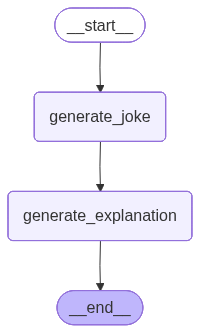

In [14]:
workflow

In [17]:
config = {"configurable": {"thread_id" : "1"}}
workflow.invoke({'topic': 'Pizza'}, config=config)

{'topic': 'Pizza',
 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!',
 'explanation': 'This joke plays on the double meaning of the word "saucy." In one sense, "saucy" can mean cheeky or impertinent, which is a playful way to describe a person or thing that is being a bit sassy or mischievous. In another sense, "saucy" can refer to food that has a lot of sauce on it. So, the joke is a pun - the pizza went to the doctor because it was feeling a little "sa'}

In [18]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." In one sense, "saucy" can mean cheeky or impertinent, which is a playful way to describe a person or thing that is being a bit sassy or mischievous. In another sense, "saucy" can refer to food that has a lot of sauce on it. So, the joke is a pun - the pizza went to the doctor because it was feeling a little "sa'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a2f99-025e-6864-8002-d97a516984df'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-06T21:15:19.744522+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a2f98-f1af-63b8-8001-bb422afcbaea'}}, tasks=(), interrupts=())

In [19]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza go to the doctor? Because it was feeling a little saucy!', 'explanation': 'This joke plays on the double meaning of the word "saucy." In one sense, "saucy" can mean cheeky or impertinent, which is a playful way to describe a person or thing that is being a bit sassy or mischievous. In another sense, "saucy" can refer to food that has a lot of sauce on it. So, the joke is a pun - the pizza went to the doctor because it was feeling a little "sa'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a2f99-025e-6864-8002-d97a516984df'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-06T21:15:19.744522+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a2f98-f1af-63b8-8001-bb422afcbaea'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza go to the doctor? Becaus